In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install torch-geometric -q

import torch

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.5 MB/s eta 0:00:00


In [ ]:
import os
import tarfile
import numpy as np
import io

circuitnet_root = '/content/drive/MyDrive/CircuitNet'

# 1. See everything actually available — don't assume, just look.
print("=" * 60)
print("CircuitNet folder structure")
print("=" * 60)
for root, dirs, files in os.walk(circuitnet_root):
    depth = root.replace(circuitnet_root, '').count(os.sep)
    indent = '  ' * depth
    print(f"{indent}{os.path.basename(root)}/")
    if depth < 3:
        for f in files:
            print(f"{indent}  {f}")

# 2. Specifically check macro_region.tar.gz (mentioned before, never opened)
print("\n" + "=" * 60)
print("Peeking into macro_region.tar.gz")
print("=" * 60)

macro_path = None
for root, dirs, files in os.walk(circuitnet_root):
    for f in files:
        if 'macro_region' in f.lower():
            macro_path = os.path.join(root, f)
            break

if macro_path is None:
    print("❌ No macro_region file found anywhere under CircuitNet/")
else:
    print(f"Found: {macro_path}")
    with tarfile.open(macro_path, 'r:gz') as tar:
        members = tar.getmembers()
        print(f"Total files inside: {len(members)}")
        print("Sample filenames:")
        for m in members[:10]:
            print(" ", m.name)

        # Load one sample file to inspect actual shape/content
        sample_member = members[0]
        file_obj = tar.extractfile(sample_member)
        arr = np.load(io.BytesIO(file_obj.read()))
        print(f"\nSample file: {sample_member.name}")
        print(f"Shape: {arr.shape}")
        print(f"Dtype: {arr.dtype}")
        print(f"Min/Max: {arr.min()}/{arr.max()}")
        print(f"Sample values:\n{arr[:5] if arr.ndim == 1 else arr[:3, :3]}")

CircuitNet folder structure
CircuitNet/
  LICENSE
  CircuitNet-N28/
    routability_features/
      macro_region.tar.gz
      cell_density.tar.gz
      DRC/
      RUDY/
      congestion/
        congestion_early_global_routing/
        congestion_global_routing/
    IR_drop_features/
      power_t.tar.gz.00
      power_s.tar.gz
      power_sca.tar.gz
      power_t.tar.gz.10
      power_all.tar.gz
      power_i.tar.gz
      power_t.tar.gz.08
      power_t.tar.gz.09
      power_t.tar.gz.06
      power_t.tar.gz.05
      power_t.tar.gz.07
      power_t.tar.gz.02
      power_t.tar.gz.01
      power_t.tar.gz.03
      power_t.tar.gz.04
      IR_drop.tar.gz
    graph_features/
      instance_placement_gcell.tar.gz
      instance_placement_micron.tar.gz
      graph_information.tar.gz
    timing_features/
      timing_features_post_route/
      pin_positions/
    raw_data/
      netlist.tar.gz
      LEF&DEF/
        route-DEF/
        place-DEF/
    preprocess_scripts/
      decompress_routabili

AttributeError: 'NoneType' object has no attribute 'read'

In [ ]:
import os

n14_root = '/content/drive/MyDrive/CircuitNet/CircuitNet-N14/graph_features'
parts = sorted([f for f in os.listdir(n14_root) if f.startswith('instance_placement_gcell.tar.gz_')])
print("Parts found:", parts)

total_size = sum(os.path.getsize(os.path.join(n14_root, p)) for p in parts)
print(f"Total combined size: {total_size / (1024**3):.2f} GB")

Parts found: ['instance_placement_gcell.tar.gz_00', 'instance_placement_gcell.tar.gz_01', 'instance_placement_gcell.tar.gz_02', 'instance_placement_gcell.tar.gz_03', 'instance_placement_gcell.tar.gz_04', 'instance_placement_gcell.tar.gz_05', 'instance_placement_gcell.tar.gz_06']
Total combined size: 12.90 GB


In [ ]:
import tarfile
import numpy as np
import io
import os

n14_root = '/content/drive/MyDrive/CircuitNet/CircuitNet-N14/graph_features'
parts = sorted([f for f in os.listdir(n14_root) if f.startswith('instance_placement_gcell.tar.gz_')])
part_paths = [os.path.join(n14_root, p) for p in parts]

class ChainedFileReader:
    def __init__(self, paths):
        self.paths = paths
        self.idx = 0
        self.current = open(self.paths[0], 'rb')

    def read(self, size=-1):
        data = self.current.read(size)
        while (size < 0 or len(data) < size) and self.idx < len(self.paths) - 1:
            self.current.close()
            self.idx += 1
            self.current = open(self.paths[self.idx], 'rb')
            remaining = -1 if size < 0 else size - len(data)
            data += self.current.read(remaining)
        return data

    def close(self):
        self.current.close()

chained = ChainedFileReader(part_paths)

print("Streaming, looking for a zero-riscy sample...")
found = False
with tarfile.open(fileobj=chained, mode='r|gz') as tar:
    for member in tar:
        if 'zero-riscy' in member.name and member.isfile():
            f = tar.extractfile(member)
            raw = np.load(io.BytesIO(f.read()), allow_pickle=True)
            obj = raw.item()  # unwrap the 0-d object array

            print(f"\nFound: {member.name}")
            print(f"Unwrapped type: {type(obj)}")

            if isinstance(obj, dict):
                print(f"Dict keys: {list(obj.keys())[:20]}")
                first_key = next(iter(obj))
                print(f"Sample entry for key '{first_key}': {obj[first_key]}")
            elif isinstance(obj, (list, tuple)):
                print(f"Length: {len(obj)}")
                print(f"First few entries: {obj[:5]}")
            elif isinstance(obj, np.ndarray):
                print(f"Inner array shape: {obj.shape}, dtype: {obj.dtype}")
                print(f"First few rows:\n{obj[:5]}")
            else:
                print(f"Value: {obj}")

            found = True
            break

chained.close()

if not found:
    print("No zero-riscy file found (unexpected).")

Streaming, looking for a zero-riscy sample...

Found: instance_placement_gcell/zero-riscy_freq_50_mp_2_fpu_65_fpa_1.0_p_7_fi_ap_detailedroute.def.gz.npy
Unwrapped type: <class 'dict'>
Dict keys: ['core_region_i/instr_mem/sp_ram_wrap_i/sp_ram_bank_i', 'core_region_i/data_mem/sp_ram_bank_i', 'PLL', 'FE_PHC66_gpio_in_29', 'FE_PHC65_gpio_in_12', 'FE_PHC64_gpio_in_24', 'FE_PHC63_gpio_in_26', 'FE_PHC62_gpio_in_10', 'FE_PHC61_gpio_in_9', 'FE_PHC60_gpio_in_8', 'FE_PHC59_gpio_in_14', 'FE_PHC57_gpio_in_7', 'FE_PHC56_gpio_in_15', 'FE_PHC55_gpio_in_4', 'FE_PHC54_gpio_in_5', 'FE_PHC51_uart_dsr', 'FE_PHC50_uart_cts', 'FE_PHC49_uart_rx', 'FE_PHC12_gpio_in_17', 'FE_OFC255_n1']
Sample entry for key 'core_region_i/instr_mem/sp_ram_wrap_i/sp_ram_bank_i': [68, 156, 146, 235]


In [ ]:
import tarfile
import os

tar_path   = '/content/drive/MyDrive/CircuitNet/CircuitNet-N14/graph_features/graph_information.tar.gz'
extract_to = '/content/graph_N14/'
os.makedirs(extract_to, exist_ok=True)

print("Re-extracting N14 graph info...")
with tarfile.open(tar_path, 'r:gz') as tar:
    tar.extractall(path=extract_to)
print(" Done!")

# Confirm it landed where expected
for root, dirs, files in os.walk(extract_to):
    print(root, '->', files[:5])

Re-extracting N14 graph info...


/tmp/ipykernel_4142/1532414297.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_to)


✅ Done!
/content/graph_N14/ -> []
/content/graph_N14/node_attr -> ['san_openc910-1_2_netlist_flatten_node_attr.npy', 'san_RISCY_5_netlist_flatten_node_attr.npy', 'san_RISCY_20_netlist_flatten_node_attr.npy', 'san_Vortex-large_5_netlist_flatten_node_attr.npy', 'san_zero-riscy_20_netlist_flatten_node_attr.npy']
/content/graph_N14/net_attr -> ['san_RISCY_20_netlist_flatten_net_attr.npy', 'san_Vortex-large_5_netlist_flatten_net_attr.npy', 'san_Vortex-large_2_netlist_flatten_net_attr.npy', 'san_Vrotex-small_2_netlist_flatten_net_attr.npy', 'san_RISCY_5_netlist_flatten_net_attr.npy']
/content/graph_N14/pin_attr -> ['san_openc910-1_2_netlist_flatten_pin_attr.npy', 'san_zero-riscy_5_netlist_flatten_pin_attr.npy', 'san_nvdla-small_2_netlist_flatten_pin_attr.npy', 'san_nvdla-small_5_netlist_flatten_pin_attr.npy', 'san_Vortex-large_5_netlist_flatten_pin_attr.npy']


In [ ]:
extract_to = '/content/graph_N14/'  # reuse from earlier if still extracted, else re-extract graph_information.tar.gz
VARIANT_N14 = 'san_zero-riscy_5_netlist_flatten'

node_n14 = np.load(f'{extract_to}/node_attr/{VARIANT_N14}_node_attr.npy', allow_pickle=True)

# node_attr row 0 = instance names (per your earlier extraction)
node_names = node_n14[0]
def unpack_name(v):
    return v[0] if isinstance(v, (list, np.ndarray)) else v

node_names_clean = [unpack_name(n) for n in node_names]
print(f"Total nodes: {len(node_names_clean)}")
print("Sample node names:", node_names_clean[:5])

placement_names = set(obj.keys())
node_names_set = set(node_names_clean)

overlap = node_names_set & placement_names
print(f"\nNodes with placement match: {len(overlap)} / {len(node_names_set)}")
print(f"Coverage: {100 * len(overlap) / len(node_names_set):.1f}%")

missing_sample = list(node_names_set - placement_names)[:5]
print(f"\nSample unmatched node names (if any): {missing_sample}")

Total nodes: 34983
Sample node names: ['\\core_region_i/data_mem_axi_if/axi_mem_if_SP_i/Slave_aw_buffer_LP/buffer_i/U13', '\\core_region_i/CORE.RISCV_CORE/id_stage_i/registers_i/U89', '\\core_region_i/CORE.RISCV_CORE/id_stage_i/registers_i/U499', '\\peripherals_i/apb_uart_i/UART_TX/U9', '\\axi_interconnect_i/axi_node_i/_RESP_BLOCK_GEN[0].RESP_BLOCK/BR_ALLOC/ARB_TREE.BR_ARB_TREE/BINARY_TREE.STAGE[0].INCR_VERT[0].LAST_NODE.FAN_IN_REQ/U21']

Nodes with placement match: 1 / 34983
Coverage: 0.0%

Sample unmatched node names (if any): ['\\core_region_i/CORE.RISCV_CORE/ex_block_i/alu_i/U519', '\\peripherals_i/axi_spi_slave_i/axi_spi_slave_i/u_dcfifo_rx/u_din/buffer/data_reg[4][6]', '\\peripherals_i/apb_spi_master_i/u_txfifo/U20', '\\peripherals_i/apb_timer_i/TIMER_GEN[0].timer_i/U464', '\\core_region_i/CORE.RISCV_CORE/id_stage_i/int_controller_i/U3']


In [ ]:
# Strip Verilog escape backslash and re-check overlap
node_names_stripped = [n.lstrip('\\') for n in node_names_clean]

overlap2 = set(node_names_stripped) & placement_names
print(f"After stripping backslash — matches: {len(overlap2)} / {len(node_names_stripped)}")
print(f"Coverage: {100 * len(overlap2) / len(node_names_stripped):.1f}%")

# How many total entries does the placement dict actually have?
print(f"\nTotal placement dict entries: {len(placement_names)}")

# Sample a broader chunk of placement keys to see the naming pattern mix
import random
sample_keys = random.sample(list(placement_names), min(20, len(placement_names)))
print("\nRandom sample of placement keys:")
for k in sample_keys:
    print(" ", k)

After stripping backslash — matches: 32378 / 34983
Coverage: 92.6%

Total placement dict entries: 85976

Random sample of placement keys:
  core_region_i/core2axi_i/core2axi_i/U7
  core_region_i/CORE.RISCV_CORE/cs_registers_i/U365
  FILLER__2_285
  FILLER__8_4029
  FILLER__3_497
  core_region_i/instr_mem/boot_rom_wrap_i/boot_code_i/U1006
  FILLER__6_5229
  FILLER__1_3707
  FILLER__2_3634
  peripherals_i/apb_spi_master_i/u_spictrl/u_clkgen/U41
  FILLER__3_2415
  FILLER__2_6099
  FILLER__1_1817
  FILLER__6_2992
  FILLER__7_4834
  core_region_i/adv_dbg_if_i/dbg_module_i/i_dbg_cpu_or1k/U121
  core_region_i/U6
  core_region_i/CORE.RISCV_CORE/id_stage_i/registers_i/mem_reg[3][5]
  FILLER__4_2269
  peripherals_i/axi2apb_i/genblk1.axi2apb_i/Slave_w_buffer/buffer_i/FIFO_REGISTERS_reg[0][18]


In [ ]:
# Build center coordinates for every matched node
node_xy = np.full((len(node_names_stripped), 2), np.nan, dtype=np.float32)

for i, name in enumerate(node_names_stripped):
    if name in obj:
        x1, y1, x2, y2 = obj[name]
        node_xy[i] = [(x1 + x2) / 2, (y1 + y2) / 2]

matched_mask = ~np.isnan(node_xy).any(axis=1)
print(f"Matched: {matched_mask.sum()} / {len(node_xy)}  ({100*matched_mask.sum()/len(node_xy):.1f}%)")

valid_xy = node_xy[matched_mask]
print(f"X range: {valid_xy[:,0].min():.1f} to {valid_xy[:,0].max():.1f}")
print(f"Y range: {valid_xy[:,1].min():.1f} to {valid_xy[:,1].max():.1f}")

# Now check RUDY map dimensions for the SAME design/config to see if grids align
import tarfile as tf
rudy_check_path = '/content/drive/MyDrive/CircuitNet/CircuitNet-N14/routability_features/RUDY/RUDY.tar.gz'
with tf.open(rudy_check_path, 'r:gz') as tar:
    for member in tar:
        if 'zero-riscy' in member.name and member.isfile():
            f = tar.extractfile(member)
            rudy_arr = np.load(io.BytesIO(f.read()))
            print(f"\nRUDY sample: {member.name}")
            print(f"RUDY map shape: {rudy_arr.shape}")
            break

Matched: 32378 / 34983  (92.6%)
X range: 9.0 to 218.0
Y range: 9.5 to 235.5

RUDY sample: RUDY/zero-riscy_freq_500_mp_2_fpu_60_fpa_1.5_p_0_fi_ap.npy
RUDY map shape: (212, 307)


In [ ]:
import tarfile, numpy as np, io

def load_matching_pair(config_suffix):
    """config_suffix e.g. 'freq_500_mp_2_fpu_60_fpa_1.5_p_0_fi_ap'"""
    placement_root = '/content/drive/MyDrive/CircuitNet/CircuitNet-N14/graph_features'
    parts = sorted([f for f in __import__('os').listdir(placement_root) if f.startswith('instance_placement_gcell.tar.gz_')])
    part_paths = [f'{placement_root}/{p}' for p in parts]
    chained = ChainedFileReader(part_paths)  # reuse from earlier

    placement_obj = None
    with tarfile.open(fileobj=chained, mode='r|gz') as tar:
        for member in tar:
            if config_suffix in member.name and 'zero-riscy' in member.name and member.isfile():
                f = tar.extractfile(member)
                placement_obj = np.load(io.BytesIO(f.read()), allow_pickle=True).item()
                print("Placement file:", member.name)
                break
    chained.close()

    rudy_arr = None
    rudy_path = '/content/drive/MyDrive/CircuitNet/CircuitNet-N14/routability_features/RUDY/RUDY.tar.gz'
    with tarfile.open(rudy_path, 'r:gz') as tar:
        for member in tar:
            if config_suffix in member.name and 'zero-riscy' in member.name and member.isfile():
                f = tar.extractfile(member)
                rudy_arr = np.load(io.BytesIO(f.read()))
                print("RUDY file:", member.name)
                break

    return placement_obj, rudy_arr

# Use the exact config identifier from your earlier placement sample
placement_obj, rudy_arr = load_matching_pair('freq_50_mp_2_fpu_65_fpa_1.0_p_7_fi_ap')

if placement_obj is None or rudy_arr is None:
    print("No matching RUDY file found for this exact config — will need to find one that exists in both.")
else:
    print(f"\nRUDY shape: {rudy_arr.shape}")

    node_xy = np.full((len(node_names_stripped), 2), np.nan, dtype=np.float32)
    for i, name in enumerate(node_names_stripped):
        if name in placement_obj:
            x1, y1, x2, y2 = placement_obj[name]
            node_xy[i] = [(x1 + x2) / 2, (y1 + y2) / 2]

    matched = ~np.isnan(node_xy).any(axis=1)
    print(f"Matched nodes: {matched.sum()} / {len(node_xy)}")

    # Try orientation A: rudy[x, y]
    xs = np.clip(node_xy[matched, 0].astype(int), 0, rudy_arr.shape[0]-1)
    ys = np.clip(node_xy[matched, 1].astype(int), 0, rudy_arr.shape[1]-1)
    labels_A = rudy_arr[xs, ys]
    print(f"\nOrientation A (rudy[x,y]): mean={labels_A.mean():.4f} std={labels_A.std():.4f}")

    # Try orientation B: rudy[y, x] (transposed)
    xs2 = np.clip(node_xy[matched, 0].astype(int), 0, rudy_arr.shape[1]-1)
    ys2 = np.clip(node_xy[matched, 1].astype(int), 0, rudy_arr.shape[0]-1)
    labels_B = rudy_arr[ys2, xs2]
    print(f"Orientation B (rudy[y,x]): mean={labels_B.mean():.4f} std={labels_B.std():.4f}")

    print(f"\nGlobal RUDY stats: mean={rudy_arr.mean():.4f} std={rudy_arr.std():.4f} min={rudy_arr.min():.4f} max={rudy_arr.max():.4f}")

Placement file: instance_placement_gcell/zero-riscy_freq_50_mp_2_fpu_65_fpa_1.0_p_7_fi_ap_detailedroute.def.gz.npy
RUDY file: RUDY/zero-riscy_freq_50_mp_2_fpu_65_fpa_1.0_p_7_fi_ap.npy

RUDY shape: (244, 246)
Matched nodes: 32378 / 34983

Orientation A (rudy[x,y]): mean=0.0090 std=0.0047
Orientation B (rudy[y,x]): mean=0.0059 std=0.0056

Global RUDY stats: mean=0.0040 std=0.0062 min=0.0000 max=0.0343


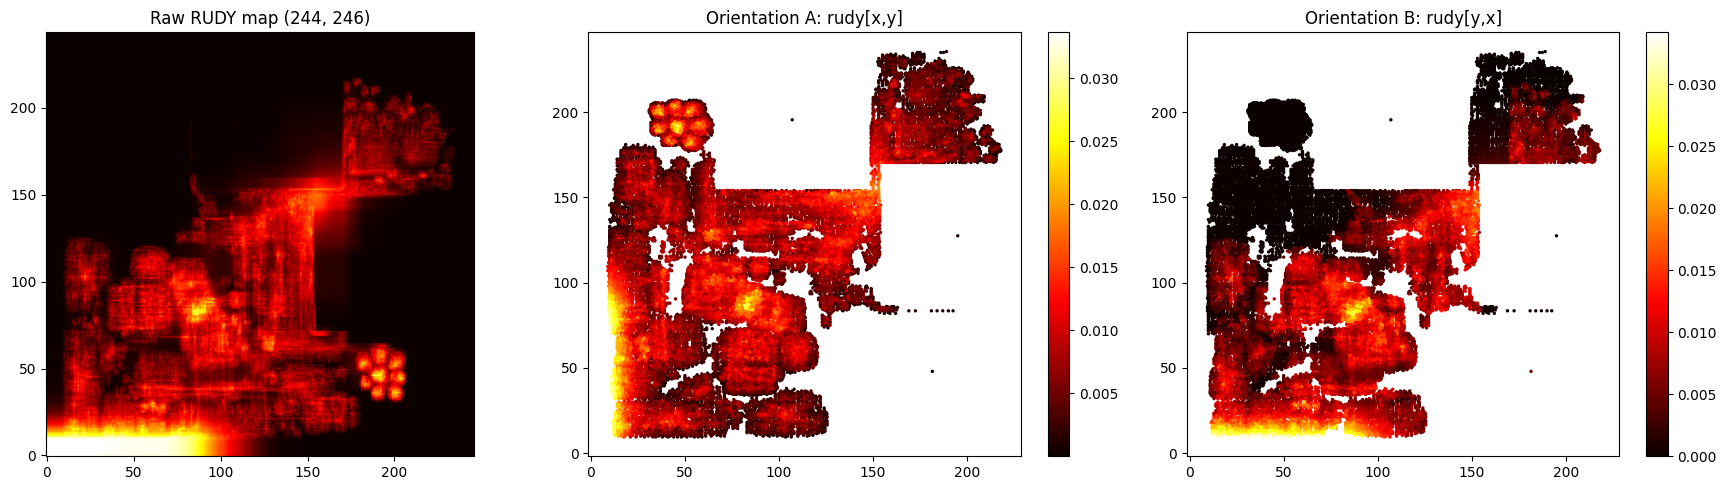

Saved to /content/orientation_check.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(rudy_arr, cmap='hot', origin='lower')
axes[0].set_title(f'Raw RUDY map {rudy_arr.shape}')

sc1 = axes[1].scatter(node_xy[matched,0], node_xy[matched,1], c=labels_A, cmap='hot', s=2)
axes[1].set_title('Orientation A: rudy[x,y]')
plt.colorbar(sc1, ax=axes[1])

sc2 = axes[2].scatter(node_xy[matched,0], node_xy[matched,1], c=labels_B, cmap='hot', s=2)
axes[2].set_title('Orientation B: rudy[y,x]')
plt.colorbar(sc2, ax=axes[2])

plt.tight_layout()
plt.savefig('/content/orientation_check.png', dpi=100)
plt.show()
print("Saved to /content/orientation_check.png")

In [ ]:
import tarfile, numpy as np, io, os

def extract_node_labels_for_config(config_suffix, node_names_stripped, placement_root, rudy_tar_path):
    """
    Returns per-node congestion labels for ONE config.
    config_suffix e.g. 'freq_50_mp_2_fpu_65_fpa_1.0_p_7_fi_ap'
    """
    # --- Load placement dict for this config ---
    parts = sorted([f for f in os.listdir(placement_root) if f.startswith('instance_placement_gcell.tar.gz_')])
    part_paths = [f'{placement_root}/{p}' for p in parts]
    chained = ChainedFileReader(part_paths)  # reuse from earlier

    placement_obj = None
    with tarfile.open(fileobj=chained, mode='r|gz') as tar:
        for member in tar:
            if config_suffix in member.name and 'zero-riscy' in member.name and member.isfile():
                f = tar.extractfile(member)
                placement_obj = np.load(io.BytesIO(f.read()), allow_pickle=True).item()
                break
    chained.close()

    if placement_obj is None:
        return None, None  # no placement file for this config

    # --- Load matching RUDY map ---
    rudy_arr = None
    with tarfile.open(rudy_tar_path, 'r:gz') as tar:
        for member in tar:
            if config_suffix in member.name and 'zero-riscy' in member.name and member.isfile():
                f = tar.extractfile(member)
                rudy_arr = np.load(io.BytesIO(f.read()))
                break

    if rudy_arr is None:
        return None, None  # no RUDY file for this config

    # --- Build per-node (x,y) centers ---
    num_nodes = len(node_names_stripped)
    node_xy = np.full((num_nodes, 2), np.nan, dtype=np.float32)
    for i, name in enumerate(node_names_stripped):
        if name in placement_obj:
            x1, y1, x2, y2 = placement_obj[name]
            node_xy[i] = [(x1 + x2) / 2, (y1 + y2) / 2]

    matched_mask = ~np.isnan(node_xy).any(axis=1)

    # --- Look up RUDY value per node using CONFIRMED orientation: rudy[x, y] ---
    node_labels = np.zeros(num_nodes, dtype=np.float32)
    xs = np.clip(node_xy[matched_mask, 0].astype(int), 0, rudy_arr.shape[0] - 1)
    ys = np.clip(node_xy[matched_mask, 1].astype(int), 0, rudy_arr.shape[1] - 1)
    node_labels[matched_mask] = rudy_arr[xs, ys]

    return node_labels, matched_mask

# --- Test on the one config we've already validated ---
placement_root = '/content/drive/MyDrive/CircuitNet/CircuitNet-N14/graph_features'
rudy_tar_path = '/content/drive/MyDrive/CircuitNet/CircuitNet-N14/routability_features/RUDY/RUDY.tar.gz'

node_labels, matched_mask = extract_node_labels_for_config(
    'freq_50_mp_2_fpu_65_fpa_1.0_p_7_fi_ap',
    node_names_stripped,
    placement_root,
    rudy_tar_path
)

print(f"Matched nodes: {matched_mask.sum()} / {len(matched_mask)}")
print(f"Label stats — mean: {node_labels[matched_mask].mean():.4f}, std: {node_labels[matched_mask].std():.4f}")
print(f"Non-zero labels: {(node_labels[matched_mask] > 0).sum()} / {matched_mask.sum()}")

Matched nodes: 32378 / 34983
Label stats — mean: 0.0090, std: 0.0047
Non-zero labels: 32378 / 32378


In [ ]:
import tarfile, os

placement_root = '/content/drive/MyDrive/CircuitNet/CircuitNet-N14/graph_features'
rudy_tar_path = '/content/drive/MyDrive/CircuitNet/CircuitNet-N14/routability_features/RUDY/RUDY.tar.gz'

# --- 1. Get all zero-riscy config names from RUDY ---
rudy_configs = set()
with tarfile.open(rudy_tar_path, 'r:gz') as tar:
    for member in tar:
        if 'zero-riscy' in member.name and member.isfile():
            fname = member.name.split('/')[-1].replace('.npy', '')
            rudy_configs.add(fname)

print(f"Total zero-riscy RUDY configs: {len(rudy_configs)}")

# --- 2. Single pass through placement archive — O(1) lookup per file, no nested loop ---
parts = sorted([f for f in os.listdir(placement_root) if f.startswith('instance_placement_gcell.tar.gz_')])
part_paths = [f'{placement_root}/{p}' for p in parts]
chained = ChainedFileReader(part_paths)

placement_configs = set()
count = 0
KNOWN_SUFFIXES = ['_detailedroute.def.gz', '_globalroute.def.gz', '.def.gz']  # trim whichever matches

with tarfile.open(fileobj=chained, mode='r|gz') as tar:
    for member in tar:
        if 'zero-riscy' in member.name and member.isfile():
            fname = member.name.split('/')[-1].replace('.npy', '')
            # strip known trailing suffix to recover the base config name
            base = fname
            for suf in KNOWN_SUFFIXES:
                if base.endswith(suf):
                    base = base[: -len(suf)]
                    break
            if base in rudy_configs:
                placement_configs.add(base)
        count += 1
        if count % 5000 == 0:
            print(f"  Scanned {count} placement entries so far...")

chained.close()

print(f"\nTotal zero-riscy placement configs found: {len(placement_configs)}")
print(f"Coverage: {100*len(placement_configs)/len(rudy_configs):.1f}%")

Total zero-riscy RUDY configs: 3441
  Scanned 5000 placement entries so far...
  Scanned 10000 placement entries so far...

Total zero-riscy placement configs found: 3425
Coverage: 99.5%


In [ ]:
import tarfile, numpy as np, io, os

placement_root = '/content/drive/MyDrive/CircuitNet/CircuitNet-N14/graph_features'
rudy_tar_path = '/content/drive/MyDrive/CircuitNet/CircuitNet-N14/routability_features/RUDY/RUDY.tar.gz'
save_dir = '/content/drive/MyDrive/PEDA_Processed'

# --- Step 1: preload all zero-riscy RUDY arrays into RAM (~1GB, one fast pass) ---
print("Preloading RUDY arrays...")
rudy_arrays = {}
with tarfile.open(rudy_tar_path, 'r:gz') as tar:
    for member in tar:
        if 'zero-riscy' in member.name and member.isfile():
            fname = member.name.split('/')[-1].replace('.npy', '')
            f = tar.extractfile(member)
            rudy_arrays[fname] = np.load(io.BytesIO(f.read())).astype(np.float32)
print(f"Loaded {len(rudy_arrays)} RUDY arrays into memory.")

# --- Step 2: single pass through placement archive, compute node labels per config ---
num_nodes = len(node_names_stripped)
KNOWN_SUFFIXES = ['_detailedroute.def.gz', '_globalroute.def.gz', '.def.gz']

parts = sorted([f for f in os.listdir(placement_root) if f.startswith('instance_placement_gcell.tar.gz_')])
part_paths = [f'{placement_root}/{p}' for p in parts]
chained = ChainedFileReader(part_paths)

config_order = []          # config names in the order we process them
all_node_labels = []       # list of (num_nodes,) arrays
all_matched_masks = []     # list of (num_nodes,) bool arrays

CHECKPOINT_EVERY = 200
processed = 0

with tarfile.open(fileobj=chained, mode='r|gz') as tar:
    for member in tar:
        if 'zero-riscy' not in member.name or not member.isfile():
            continue

        fname = member.name.split('/')[-1].replace('.npy', '')
        base = fname
        for suf in KNOWN_SUFFIXES:
            if base.endswith(suf):
                base = base[: -len(suf)]
                break

        if base not in rudy_arrays:
            continue  # no matching RUDY label for this placement file

        f = tar.extractfile(member)
        placement_obj = np.load(io.BytesIO(f.read()), allow_pickle=True).item()
        rudy_arr = rudy_arrays[base]

        node_xy = np.full((num_nodes, 2), np.nan, dtype=np.float32)
        for i, name in enumerate(node_names_stripped):
            if name in placement_obj:
                x1, y1, x2, y2 = placement_obj[name]
                node_xy[i] = [(x1 + x2) / 2, (y1 + y2) / 2]

        matched = ~np.isnan(node_xy).any(axis=1)
        labels = np.zeros(num_nodes, dtype=np.float32)
        xs = np.clip(node_xy[matched, 0].astype(int), 0, rudy_arr.shape[0] - 1)
        ys = np.clip(node_xy[matched, 1].astype(int), 0, rudy_arr.shape[1] - 1)
        labels[matched] = rudy_arr[xs, ys]  # CONFIRMED orientation: rudy[x, y]

        config_order.append(base)
        all_node_labels.append(labels)
        all_matched_masks.append(matched)
        processed += 1

        if processed % CHECKPOINT_EVERY == 0:
            print(f"  Processed {processed} configs so far... (checkpointing)")
            np.save(f'{save_dir}/n14_node_labels_checkpoint.npy', np.stack(all_node_labels))
            np.save(f'{save_dir}/n14_node_matched_checkpoint.npy', np.stack(all_matched_masks))
            with open(f'{save_dir}/n14_node_config_order_checkpoint.txt', 'w') as cf:
                cf.write('\n'.join(config_order))

chained.close()
print(f"\n✅ Done! Total configs with node-level labels: {processed}")

# --- Final save ---
node_labels_all = np.stack(all_node_labels)      # shape (num_matched_configs, num_nodes)
node_matched_all = np.stack(all_matched_masks)   # shape (num_matched_configs, num_nodes)

np.save(f'{save_dir}/n14_node_labels.npy', node_labels_all)
np.save(f'{save_dir}/n14_node_matched_mask.npy', node_matched_all)
with open(f'{save_dir}/n14_node_config_order.txt', 'w') as cf:
    cf.write('\n'.join(config_order))

print(f"Saved: n14_node_labels.npy  shape={node_labels_all.shape}")
print(f"Saved: n14_node_matched_mask.npy  shape={node_matched_all.shape}")

Preloading RUDY arrays...
Loaded 3441 RUDY arrays into memory.
  Processed 200 configs so far... (checkpointing)
  Processed 400 configs so far... (checkpointing)
  Processed 600 configs so far... (checkpointing)
  Processed 800 configs so far... (checkpointing)
  Processed 1000 configs so far... (checkpointing)
  Processed 1200 configs so far... (checkpointing)
  Processed 1400 configs so far... (checkpointing)
  Processed 1600 configs so far... (checkpointing)
  Processed 1800 configs so far... (checkpointing)
  Processed 2000 configs so far... (checkpointing)
  Processed 2200 configs so far... (checkpointing)
  Processed 2400 configs so far... (checkpointing)
  Processed 2600 configs so far... (checkpointing)
  Processed 2800 configs so far... (checkpointing)
  Processed 3000 configs so far... (checkpointing)
  Processed 3200 configs so far... (checkpointing)
  Processed 3400 configs so far... (checkpointing)

✅ Done! Total configs with node-level labels: 3425
Saved: n14_node_labels

In [ ]:
import os

save_dir = '/content/drive/MyDrive/PEDA_Processed'

# Remove checkpoint files now that final save succeeded
for f in ['n14_node_labels_checkpoint.npy', 'n14_node_matched_checkpoint.npy', 'n14_node_config_order_checkpoint.txt']:
    path = f'{save_dir}/{f}'
    if os.path.exists(path):
        os.remove(path)
        print(f"Deleted: {f}")

# Sanity check on final data
node_labels_all = np.load(f'{save_dir}/n14_node_labels.npy')
node_matched_all = np.load(f'{save_dir}/n14_node_matched_mask.npy')

print(f"\nShape: {node_labels_all.shape}")
print(f"Matched nodes per config — mean: {node_matched_all.sum(axis=1).mean():.0f} / {node_labels_all.shape[1]}")
print(f"Any NaN/Inf: {np.isnan(node_labels_all).any()} / {np.isinf(node_labels_all).any()}")
print(f"Label range (matched only): min={node_labels_all[node_matched_all].min():.4f}, max={node_labels_all[node_matched_all].max():.4f}")
print(f"Label mean (matched only): {node_labels_all[node_matched_all].mean():.4f}")

# Disk usage check
total_mb = sum(os.path.getsize(f'{save_dir}/{f}') for f in os.listdir(save_dir)) / (1024**2)
print(f"\nTotal PEDA_Processed folder size: {total_mb:.1f} MB")

Deleted: n14_node_labels_checkpoint.npy
Deleted: n14_node_matched_checkpoint.npy
Deleted: n14_node_config_order_checkpoint.txt

Shape: (3425, 34983)
Matched nodes per config — mean: 32308 / 34983
Any NaN/Inf: False / False
Label range (matched only): min=0.0000, max=0.0457
Label mean (matched only): 0.0100

Total PEDA_Processed folder size: 1109.6 MB


In [ ]:
import torch, gc
torch.cuda.empty_cache()
gc.collect()

import torch.nn as nn, torch.nn.functional as F
import numpy as np
from torch_geometric.nn import GCNConv

save_dir = '/content/drive/MyDrive/PEDA_Processed'

# --- Load node-level data ---
n14_node_labels = np.load(f'{save_dir}/n14_node_labels.npy')
n14_node_matched = np.load(f'{save_dir}/n14_node_matched_mask.npy')
with open(f'{save_dir}/n14_node_config_order.txt') as f:
    config_order = f.read().splitlines()

n14_base_x = torch.load(f'{save_dir}/n14_base_x.pt').float()
n14_edge_index = torch.load(f'{save_dir}/n14_edge_index.pt').long()
cfg_mean = np.load(f'{save_dir}/n14_config_mean.npy')
cfg_std = np.load(f'{save_dir}/n14_config_std.npy')

def parse_n14_config(fname):
    parts = fname.replace('.npy', '').split('_')
    return np.array([
        float(parts[parts.index('freq') + 1]), float(parts[parts.index('mp') + 1]),
        float(parts[parts.index('fpu') + 1]), float(parts[parts.index('fpa') + 1]),
        float(parts[parts.index('p') + 1]),
    ], dtype=np.float32)

configs_raw = np.stack([parse_n14_config(name) for name in config_order])
configs_norm = (configs_raw - cfg_mean) / cfg_std
print(f"Configs: {configs_norm.shape}, Node labels: {n14_node_labels.shape}")

SEED = 42
n_configs = len(config_order)
g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(n_configs, generator=g).numpy()
n_train = int(0.8 * n_configs)
train_idx, val_idx = perm[:n_train], perm[n_train:]
print(f"Train configs: {len(train_idx)}, Val configs: {len(val_idx)}")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
n14_base_x, n14_edge_index = n14_base_x.to(device), n14_edge_index.to(device)
node_labels_t = torch.from_numpy(n14_node_labels).float().to(device)
node_matched_t = torch.from_numpy(n14_node_matched).bool().to(device)
configs_t = torch.from_numpy(configs_norm).float().to(device)

train_mask = node_matched_t[train_idx]
train_vals = node_labels_t[train_idx][train_mask]
node_label_mean, node_label_std = train_vals.mean().item(), train_vals.std().item()
print(f"Node label norm: mean={node_label_mean:.4f}, std={node_label_std:.4f}")

def norm_labels(y): return (y - node_label_mean) / node_label_std
def denorm_labels(y): return y * node_label_std + node_label_mean

class NodeLevelGNN(nn.Module):
    def __init__(self, base_in=2, cfg_dim_in=5, hidden=64, graph_dim=32, cfg_dim=16, dropout=0.10):
        super().__init__()
        self.conv1 = GCNConv(base_in, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.conv3 = GCNConv(hidden, graph_dim)
        self.dropout = dropout
        self.cfg_encoder = nn.Sequential(nn.Linear(cfg_dim_in, 32), nn.ReLU(), nn.Linear(32, cfg_dim), nn.ReLU())
        self.node_head = nn.Sequential(
            nn.Linear(graph_dim + cfg_dim, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1)
        )
    def encode_nodes(self, x_base, edge_index):
        h = F.relu(self.conv1(x_base, edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(self.conv2(h, edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = self.conv3(h, edge_index)
        return h
    def forward(self, x_base, edge_index, cfg_batch):
        h = self.encode_nodes(x_base, edge_index)
        c = self.cfg_encoder(cfg_batch)
        num_nodes = h.shape[0]
        h_exp = h.unsqueeze(0).expand(cfg_batch.shape[0], -1, -1)
        c_exp = c.unsqueeze(1).expand(-1, num_nodes, -1)
        z = torch.cat([h_exp, c_exp], dim=-1)
        return self.node_head(z).squeeze(-1)

model = NodeLevelGNN().to(device)
model.load_state_dict(torch.load(f'{save_dir}/node_level_gnn.pt', map_location=device, weights_only=True))
model.eval()
print("✅ Loaded trained node-level model (skipped retraining)")

Configs: (3425, 5), Node labels: (3425, 34983)
Train configs: 2740, Val configs: 685
Node label norm: mean=0.0100, std=0.0049
✅ Loaded trained node-level model (skipped retraining)


In [ ]:
import tarfile, os, io

# --- Re-extract N14 graph info (node names) ---
tar_path = '/content/drive/MyDrive/CircuitNet/CircuitNet-N14/graph_features/graph_information.tar.gz'
extract_to = '/content/graph_N14/'
os.makedirs(extract_to, exist_ok=True)

with tarfile.open(tar_path, 'r:gz') as tar:
    tar.extractall(path=extract_to)

VARIANT_N14 = 'san_zero-riscy_5_netlist_flatten'
node_n14 = np.load(f'{extract_to}/node_attr/{VARIANT_N14}_node_attr.npy', allow_pickle=True)

def unpack_name(v):
    return v[0] if isinstance(v, (list, np.ndarray)) else v

node_names_clean = [unpack_name(n) for n in node_n14[0]]
node_names_stripped = [n.lstrip('\\') for n in node_names_clean]
print(f"Rebuilt node names: {len(node_names_stripped)}")

# --- Chained reader needed for placement files (also from earlier session) ---
class ChainedFileReader:
    def __init__(self, paths):
        self.paths = paths
        self.idx = 0
        self.current = open(self.paths[0], 'rb')

    def read(self, size=-1):
        data = self.current.read(size)
        while (size < 0 or len(data) < size) and self.idx < len(self.paths) - 1:
            self.current.close()
            self.idx += 1
            self.current = open(self.paths[self.idx], 'rb')
            remaining = -1 if size < 0 else size - len(data)
            data += self.current.read(remaining)
        return data

    def close(self):
        self.current.close()

/tmp/ipykernel_793/1738195008.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_to)


Rebuilt node names: 34983


=== Spatial reconstruction for: zero-riscy_freq_500_mp_2_fpu_60_fpa_1.0_p_3_fi_ar ===
  Found zero-riscy_freq_500_mp_2_fpu_60_fpa_1.0_p_3_fi_ar (0 remaining)

SSIM (predicted grid vs real RUDY map): 0.5672


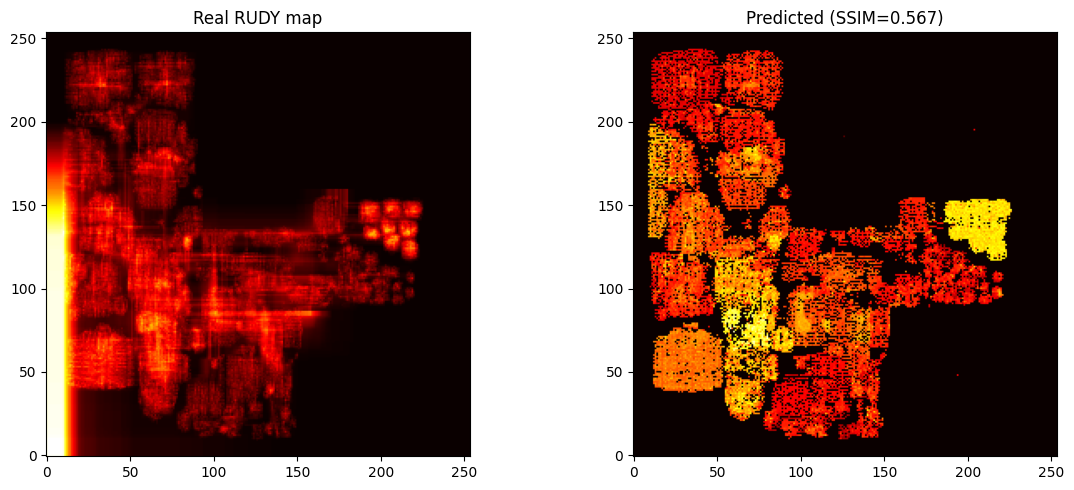

In [ ]:
import tarfile, os, io
import numpy as np
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt

# --- Faster: single-pass loader for placement data ---
def load_placement_for_multiple_configs(config_names, placement_root):
    parts = sorted([f for f in os.listdir(placement_root) if f.startswith('instance_placement_gcell.tar.gz_')])
    part_paths = [f'{placement_root}/{p}' for p in parts]
    chained = ChainedFileReader(part_paths)

    remaining = set(config_names)
    results = {}

    with tarfile.open(fileobj=chained, mode='r|gz') as tar:
        for member in tar:
            if not member.isfile() or not remaining:
                continue
            for cname in list(remaining):
                if cname in member.name:
                    f = tar.extractfile(member)
                    results[cname] = np.load(io.BytesIO(f.read()), allow_pickle=True).item()
                    remaining.remove(cname)
                    print(f"  Found {cname} ({len(remaining)} remaining)")
                    break
            if not remaining:
                break

    chained.close()
    return results

# --- Pick sample config ---
sample_config_idx = val_idx[0]
sample_name = config_order[sample_config_idx]
print(f"=== Spatial reconstruction for: {sample_name} ===")

placement_root = '/content/drive/MyDrive/CircuitNet/CircuitNet-N14/graph_features'
placement_results = load_placement_for_multiple_configs([sample_name], placement_root)
placement_obj = placement_results[sample_name]

# --- Model prediction for this config ---
model.eval()
with torch.no_grad():
    pred_norm = model(n14_base_x, n14_edge_index, configs_t[sample_config_idx:sample_config_idx+1])
    pred_raw = denorm_labels(pred_norm).cpu().numpy()[0]

target_raw = n14_node_labels[sample_config_idx]
matched = n14_node_matched[sample_config_idx]

# --- Rebuild node (x,y) positions ---
node_xy_arr = np.full((len(node_names_stripped), 2), np.nan, dtype=np.float32)
for i, name in enumerate(node_names_stripped):
    if name in placement_obj:
        x1, y1, x2, y2 = placement_obj[name]
        node_xy_arr[i] = [(x1 + x2) / 2, (y1 + y2) / 2]

# --- Load real RUDY map for comparison ---
rudy_tar_path = '/content/drive/MyDrive/CircuitNet/CircuitNet-N14/routability_features/RUDY/RUDY.tar.gz'
real_rudy = None
with tarfile.open(rudy_tar_path, 'r:gz') as tar:
    for member in tar:
        if sample_name in member.name and member.isfile():
            f = tar.extractfile(member)
            real_rudy = np.load(io.BytesIO(f.read()))
            break

grid_shape = real_rudy.shape
pred_grid = np.zeros(grid_shape, dtype=np.float32)
count_grid = np.zeros(grid_shape, dtype=np.float32)

valid = matched & ~np.isnan(node_xy_arr).any(axis=1)
xs = np.clip(node_xy_arr[valid, 0].astype(int), 0, grid_shape[0]-1)
ys = np.clip(node_xy_arr[valid, 1].astype(int), 0, grid_shape[1]-1)

np.add.at(pred_grid, (xs, ys), pred_raw[valid])
np.add.at(count_grid, (xs, ys), 1)
pred_grid_avg = np.divide(pred_grid, count_grid, out=np.zeros_like(pred_grid), where=count_grid > 0)

score = ssim(real_rudy, pred_grid_avg, data_range=real_rudy.max() - real_rudy.min())
print(f"\nSSIM (predicted grid vs real RUDY map): {score:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(real_rudy, cmap='hot', origin='lower')
axes[0].set_title('Real RUDY map')
axes[1].imshow(pred_grid_avg, cmap='hot', origin='lower')
axes[1].set_title(f'Predicted (SSIM={score:.3f})')
plt.tight_layout()
plt.savefig('/content/node_level_reconstruction.png', dpi=100)
plt.show()

Testing configs: ['zero-riscy_freq_50_mp_1_fpu_70_fpa_1.5_p_1_fi_ar', 'zero-riscy_freq_50_mp_2_fpu_50_fpa_1.5_p_3_fi_ap']
  Found zero-riscy_freq_50_mp_2_fpu_50_fpa_1.5_p_3_fi_ap (1 remaining)
  Found zero-riscy_freq_50_mp_1_fpu_70_fpa_1.5_p_1_fi_ar (0 remaining)

zero-riscy_freq_50_mp_1_fpu_70_fpa_1.5_p_1_fi_ar
SSIM: 0.4462

zero-riscy_freq_50_mp_2_fpu_50_fpa_1.5_p_3_fi_ap
SSIM: 0.6116


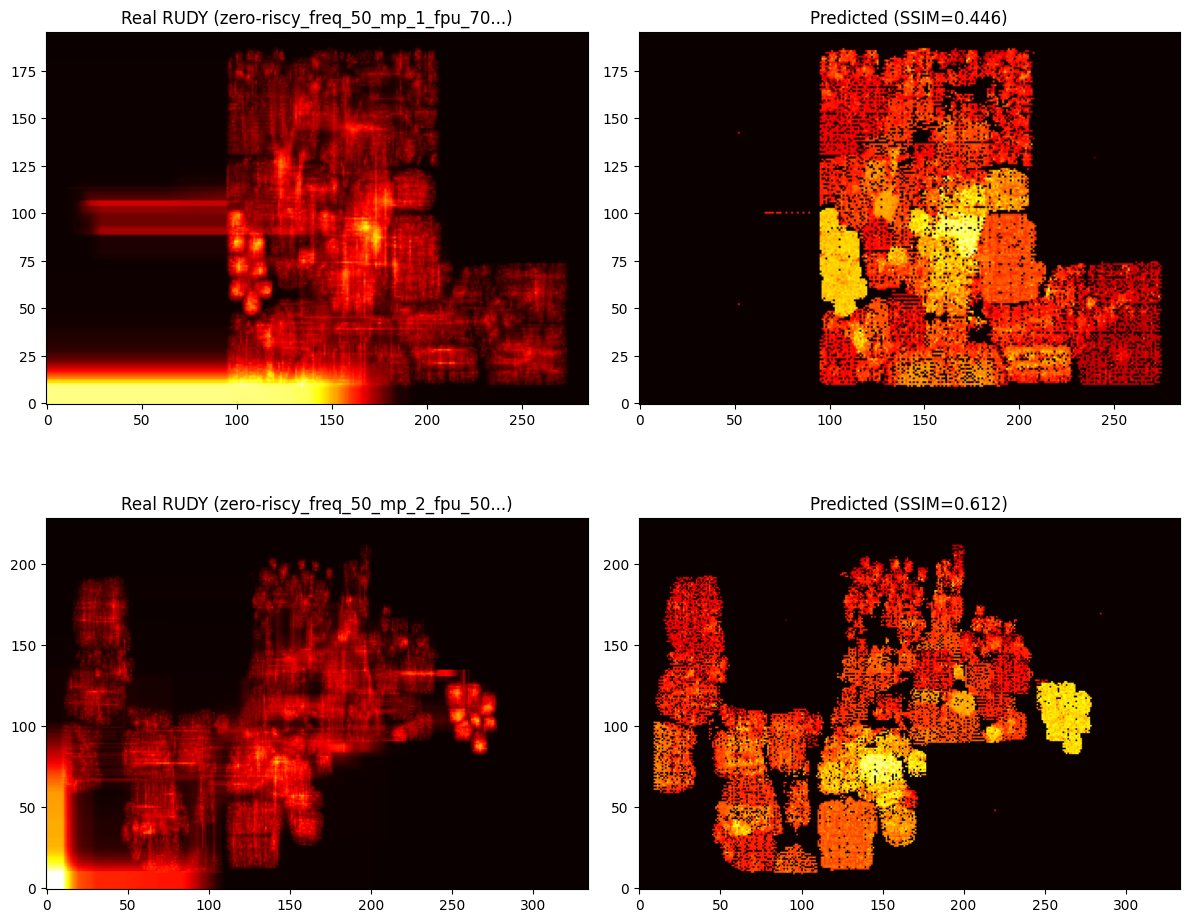

In [ ]:
import tarfile, os, io
import numpy as np
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt

# --- Pick 2 more validation configs (different from the one already tested) ---
sample_indices = [val_idx[1], val_idx[2]]
sample_names = [config_order[i] for i in sample_indices]
print(f"Testing configs: {sample_names}")

placement_root = '/content/drive/MyDrive/CircuitNet/CircuitNet-N14/graph_features'
rudy_tar_path = '/content/drive/MyDrive/CircuitNet/CircuitNet-N14/routability_features/RUDY/RUDY.tar.gz'

# --- One pass, grab both placement dicts at once ---
placement_results = load_placement_for_multiple_configs(sample_names, placement_root)

# --- One pass through RUDY tar, grab both real maps at once ---
rudy_results = {}
remaining = set(sample_names)
with tarfile.open(rudy_tar_path, 'r:gz') as tar:
    for member in tar:
        if not member.isfile() or not remaining:
            continue
        for cname in list(remaining):
            if cname in member.name:
                f = tar.extractfile(member)
                rudy_results[cname] = np.load(io.BytesIO(f.read()))
                remaining.remove(cname)
                break
        if not remaining:
            break

# --- Run reconstruction + SSIM for each ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for row, (sample_config_idx, sample_name) in enumerate(zip(sample_indices, sample_names)):
    placement_obj = placement_results[sample_name]
    real_rudy = rudy_results[sample_name]

    model.eval()
    with torch.no_grad():
        pred_norm = model(n14_base_x, n14_edge_index, configs_t[sample_config_idx:sample_config_idx+1])
        pred_raw = denorm_labels(pred_norm).cpu().numpy()[0]

    matched = n14_node_matched[sample_config_idx]

    node_xy_arr = np.full((len(node_names_stripped), 2), np.nan, dtype=np.float32)
    for i, name in enumerate(node_names_stripped):
        if name in placement_obj:
            x1, y1, x2, y2 = placement_obj[name]
            node_xy_arr[i] = [(x1 + x2) / 2, (y1 + y2) / 2]

    grid_shape = real_rudy.shape
    pred_grid = np.zeros(grid_shape, dtype=np.float32)
    count_grid = np.zeros(grid_shape, dtype=np.float32)

    valid = matched & ~np.isnan(node_xy_arr).any(axis=1)
    xs = np.clip(node_xy_arr[valid, 0].astype(int), 0, grid_shape[0]-1)
    ys = np.clip(node_xy_arr[valid, 1].astype(int), 0, grid_shape[1]-1)

    np.add.at(pred_grid, (xs, ys), pred_raw[valid])
    np.add.at(count_grid, (xs, ys), 1)
    pred_grid_avg = np.divide(pred_grid, count_grid, out=np.zeros_like(pred_grid), where=count_grid > 0)

    score = ssim(real_rudy, pred_grid_avg, data_range=real_rudy.max() - real_rudy.min())
    print(f"\n{sample_name}\nSSIM: {score:.4f}")

    axes[row, 0].imshow(real_rudy, cmap='hot', origin='lower')
    axes[row, 0].set_title(f'Real RUDY ({sample_name[:30]}...)')
    axes[row, 1].imshow(pred_grid_avg, cmap='hot', origin='lower')
    axes[row, 1].set_title(f'Predicted (SSIM={score:.3f})')

plt.tight_layout()
plt.savefig('/content/multi_sample_ssim.png', dpi=100)
plt.show()

In [ ]:
import numpy as np
import torch
from scipy.stats import pearsonr
from scipy.spatial import cKDTree

# --- Preload all 3 configs' placement data in ONE pass ---
sample_indices = [val_idx[0], val_idx[1], val_idx[2]]
sample_names = [config_order[i] for i in sample_indices]
placement_root = '/content/drive/MyDrive/CircuitNet/CircuitNet-N14/graph_features'

print("Preloading all 3 placement files in one pass...")
placement_results = load_placement_for_multiple_configs(sample_names, placement_root)
print("Done preloading.\n")

def explain_config(sample_config_idx, placement_obj, top_k=20, density_radius=5.0):
    sample_name = config_order[sample_config_idx]
    print(f"=== Explaining: {sample_name} ===\n")

    node_xy_arr = np.full((len(node_names_stripped), 2), np.nan, dtype=np.float32)
    for i, name in enumerate(node_names_stripped):
        if name in placement_obj:
            x1, y1, x2, y2 = placement_obj[name]
            node_xy_arr[i] = [(x1 + x2) / 2, (y1 + y2) / 2]

    matched = n14_node_matched[sample_config_idx]
    valid = matched & ~np.isnan(node_xy_arr).any(axis=1)
    valid_idx = np.where(valid)[0]

    model.eval()
    x_base = n14_base_x.clone().requires_grad_(True)
    pred_norm = model(x_base, n14_edge_index, configs_t[sample_config_idx:sample_config_idx+1])
    pred_raw = denorm_labels(pred_norm)[0]
    pred_raw_np = pred_raw.detach().cpu().numpy()

    print("--- Global feature correlation (this config) ---")
    degree = n14_base_x[:, 0].cpu().numpy()[valid_idx]
    fanout = n14_base_x[:, 1].cpu().numpy()[valid_idx]
    preds_valid = pred_raw_np[valid_idx]

    r_degree, _ = pearsonr(degree, preds_valid)
    r_fanout, _ = pearsonr(fanout, preds_valid)
    print(f"Degree vs predicted congestion:  r = {r_degree:.4f}")
    print(f"Avg fanout vs predicted congestion: r = {r_fanout:.4f}")

    xy_valid = node_xy_arr[valid_idx]
    tree = cKDTree(xy_valid)
    neighbor_counts = tree.query_ball_point(xy_valid, r=density_radius, return_length=True)
    r_density, _ = pearsonr(neighbor_counts, preds_valid)
    print(f"Local placement density vs predicted congestion: r = {r_density:.4f}")

    print(f"\n--- Top-{top_k} hotspot saliency ---")
    top_hotspot_local_idx = np.argsort(preds_valid)[-top_k:]
    top_hotspot_global_idx = valid_idx[top_hotspot_local_idx]

    hotspot_sum = pred_raw[top_hotspot_global_idx].sum()
    hotspot_sum.backward()

    grad = x_base.grad[top_hotspot_global_idx].cpu().numpy()
    mean_grad_degree = grad[:, 0].mean()
    mean_grad_fanout = grad[:, 1].mean()

    print(f"Mean sensitivity to degree (∂pred/∂degree):  {mean_grad_degree:.6f}")
    print(f"Mean sensitivity to avg_fanout (∂pred/∂fanout): {mean_grad_fanout:.6f}")

    dominant = "degree" if abs(mean_grad_degree) > abs(mean_grad_fanout) else "avg_fanout"
    print(f"\n→ Model is more sensitive to: {dominant}")

    return {'r_degree': r_degree, 'r_fanout': r_fanout, 'r_density': r_density,
            'grad_degree': mean_grad_degree, 'grad_fanout': mean_grad_fanout}

results = []
for idx, name in zip(sample_indices, sample_names):
    results.append(explain_config(idx, placement_results[name]))
    print()

Preloading all 3 placement files in one pass...
  Found zero-riscy_freq_50_mp_2_fpu_50_fpa_1.5_p_3_fi_ap (2 remaining)
  Found zero-riscy_freq_50_mp_1_fpu_70_fpa_1.5_p_1_fi_ar (1 remaining)
  Found zero-riscy_freq_500_mp_2_fpu_60_fpa_1.0_p_3_fi_ar (0 remaining)
Done preloading.

=== Explaining: zero-riscy_freq_500_mp_2_fpu_60_fpa_1.0_p_3_fi_ar ===

--- Global feature correlation (this config) ---
Degree vs predicted congestion:  r = 0.1021
Avg fanout vs predicted congestion: r = -0.3553
Local placement density vs predicted congestion: r = 0.4285

--- Top-20 hotspot saliency ---
Mean sensitivity to degree (∂pred/∂degree):  0.001237
Mean sensitivity to avg_fanout (∂pred/∂fanout): 0.006580

→ Model is more sensitive to: avg_fanout

=== Explaining: zero-riscy_freq_50_mp_1_fpu_70_fpa_1.5_p_1_fi_ar ===

--- Global feature correlation (this config) ---
Degree vs predicted congestion:  r = 0.0696
Avg fanout vs predicted congestion: r = -0.3898
Local placement density vs predicted congestion: r

In [ ]:
# Global correlation strengths (from your Explain stage) — used as importance weights
FEATURE_WEIGHTS = {
    'density': abs(np.mean([0.4285, 0.5271, 0.5020])),  # ~0.486
    'fanout':  abs(np.mean([0.3553, 0.3898, 0.3416])),  # ~0.362 (magnitude, direction handled separately)
    'degree':  abs(np.mean([0.1021, 0.0696, 0.0870])),  # ~0.086
}

def recommend_for_config_weighted(sample_config_idx, placement_obj, top_k=10, density_radius=5.0):
    sample_name = config_order[sample_config_idx]
    print(f"\n{'='*70}\n RECOMMENDATIONS (weighted): {sample_name}\n{'='*70}")

    node_xy_arr = np.full((len(node_names_stripped), 2), np.nan, dtype=np.float32)
    for i, name in enumerate(node_names_stripped):
        if name in placement_obj:
            x1, y1, x2, y2 = placement_obj[name]
            node_xy_arr[i] = [(x1 + x2) / 2, (y1 + y2) / 2]

    matched = n14_node_matched[sample_config_idx]
    valid = matched & ~np.isnan(node_xy_arr).any(axis=1)
    valid_idx = np.where(valid)[0]

    model.eval()
    with torch.no_grad():
        pred_norm = model(n14_base_x, n14_edge_index, configs_t[sample_config_idx:sample_config_idx+1])
        pred_raw = denorm_labels(pred_norm)[0].cpu().numpy()

    degree = n14_base_x[:, 0].cpu().numpy()[valid_idx]
    fanout = n14_base_x[:, 1].cpu().numpy()[valid_idx]
    preds_valid = pred_raw[valid_idx]
    xy_valid = node_xy_arr[valid_idx]

    tree = cKDTree(xy_valid)
    density = np.array(tree.query_ball_point(xy_valid, r=density_radius, return_length=True))

    density_pct = density.argsort().argsort() / len(density)
    fanout_pct = fanout.argsort().argsort() / len(fanout)
    degree_pct = degree.argsort().argsort() / len(degree)

    # NEW: weight percentile by global feature importance
    weighted_scores = {
        'density': density_pct * FEATURE_WEIGHTS['density'],
        'fanout':  fanout_pct  * FEATURE_WEIGHTS['fanout'],
        'degree':  degree_pct  * FEATURE_WEIGHTS['degree'],
    }

    top_local_idx = np.argsort(preds_valid)[-top_k:][::-1]

    for rank, local_idx in enumerate(top_local_idx, 1):
        scores = {k: v[local_idx] for k, v in weighted_scores.items()}
        dominant = max(scores, key=scores.get)
        rec = RECOMMENDATIONS[dominant]

        x, y = xy_valid[local_idx]
        print(f"\nHotspot #{rank} — location ({x:.0f}, {y:.0f}), predicted congestion={preds_valid[local_idx]:.4f}")
        print(f"  Dominant factor: {dominant} (weighted score={scores[dominant]:.3f})")
        print(f"  Likely cause: {rec['cause']}")
        print(f"  Suggested mitigation: {rec['action']}")

for idx, name in zip(sample_indices, sample_names):
    recommend_for_config_weighted(idx, placement_results[name])


 RECOMMENDATIONS (weighted): zero-riscy_freq_500_mp_2_fpu_60_fpa_1.0_p_3_fi_ar

Hotspot #1 — location (83, 58), predicted congestion=0.0168
  Dominant factor: density (weighted score=0.333)
  Likely cause: High local cell placement density
  Suggested mitigation: Increase whitespace / apply macro or cell re-placement to spread density in this region

Hotspot #2 — location (77, 68), predicted congestion=0.0164
  Dominant factor: fanout (weighted score=0.132)
  Likely cause: High local net fanout
  Suggested mitigation: Insert buffers or split high-fanout nets to reduce local routing demand

Hotspot #3 — location (77, 69), predicted congestion=0.0164
  Dominant factor: density (weighted score=0.250)
  Likely cause: High local cell placement density
  Suggested mitigation: Increase whitespace / apply macro or cell re-placement to spread density in this region

Hotspot #4 — location (76, 58), predicted congestion=0.0163
  Dominant factor: fanout (weighted score=0.201)
  Likely cause: High